In [94]:
import torch
import torch.nn as nn

data = ['The','cat','sat','down']
d_model = 8
d_k = 4
d_v =4
torch.manual_seed(1337)

X = torch.randn( size=(1,4,d_model))

In [95]:
d_k = 3
d_v =6

key = nn.Linear(d_model,d_k,bias =False)
query = nn.Linear(d_model,d_k,bias =False)
value = nn.Linear(d_model,d_v,bias =False)

Q = query(X)
K = key(X)
V = value(X)

In [96]:
print(Q.shape)
print(K.shape)
print(V.shape)

print(query.weight.shape)
print(key.weight.shape)
print(value.weight.shape)

torch.Size([1, 4, 3])
torch.Size([1, 4, 3])
torch.Size([1, 4, 6])
torch.Size([3, 8])
torch.Size([3, 8])
torch.Size([6, 8])


In [97]:
raw_scores = Q @ K.transpose(-2,-1)
raw_scores = raw_scores.detach()
raw_scores = raw_scores/(d_k ** 0.5)

In [98]:
print(raw_scores.shape)
print(raw_scores)

torch.Size([1, 4, 4])
tensor([[[ 0.1055,  0.1921,  0.0640,  0.1795],
         [ 0.2970,  0.2006,  0.0627,  0.4329],
         [-0.3965, -0.1732, -0.1460, -0.4598],
         [-0.0254,  0.1320, -0.0599,  0.1041]]])


In [99]:
from torch.nn import functional as F

wei = raw_scores
tril = torch.tril(torch.ones(4,4))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei,dim =-1)
print(wei)
print(wei.sum(dim = -1))
print(wei.shape)

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.5241, 0.4759, 0.0000, 0.0000],
         [0.2829, 0.3537, 0.3634, 0.0000],
         [0.2339, 0.2738, 0.2260, 0.2663]]])
tensor([[1., 1., 1., 1.]])
torch.Size([1, 4, 4])


In [100]:
output = wei @ V

In [101]:
print(output)
print(output.shape)

tensor([[[ 0.2608,  0.0804, -0.4088,  0.2697, -0.0554,  0.2315],
         [ 0.0494,  0.1210,  0.2126,  0.3535, -0.1656,  0.3910],
         [-0.0390,  0.1139,  0.5823,  0.3743,  0.3463,  0.0417],
         [-0.1846,  0.3115,  0.4176,  0.5039,  0.5634,  0.4799]]],
       grad_fn=<UnsafeViewBackward0>)
torch.Size([1, 4, 6])


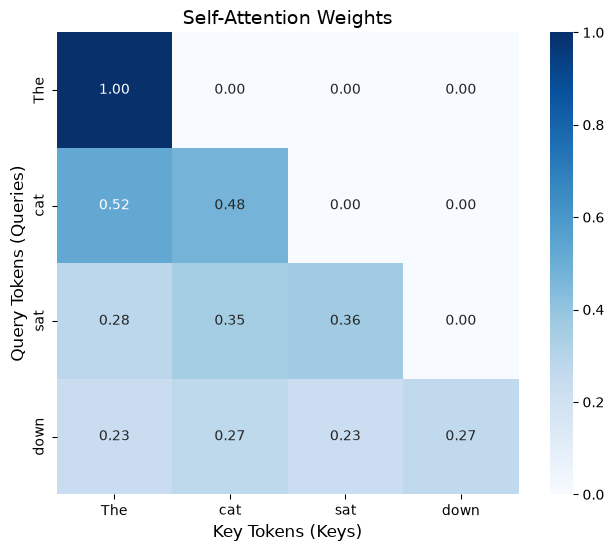

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
# 1. If batched (B, T, T), pick the first batch: wei[0]
# 2. Detach from computation graph and convert to numpy
attn_matrix = wei[0].detach().cpu().numpy()  # shape: (T, T)
plt.figure(figsize=(8, 6))
sns.heatmap(
    attn_matrix,
    cmap="Blues",       # Colormap (e.g., 'viridis', 'Blues', 'magma', 'rocket')
    annot=True,         # Set to True to display the probability values inside cells
    fmt=".2f",          # 2 decimal places
    cbar=True,          # Show colorbar
    square=True,        # Keep square aspect ratio
    vmin=0.0,
    vmax=1.0,
    xticklabels= data,
    yticklabels= data           
)
plt.title("Self-Attention Weights", fontsize=14)
plt.xlabel("Key Tokens (Keys)", fontsize=12)
plt.ylabel("Query Tokens (Queries)", fontsize=12)
plt.show()

In [103]:
print(X.shape)
print(Q.shape)
print(K.shape)
print(V.shape)
print(K.transpose(-2,-1).shape)
print(raw_scores.shape)
print(wei.shape)
print(output.shape)

torch.Size([1, 4, 8])
torch.Size([1, 4, 3])
torch.Size([1, 4, 3])
torch.Size([1, 4, 6])
torch.Size([1, 3, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 6])


In [104]:
out = torch.zeros((1,4,6),dtype = V.dtype)

for t in range(4):
    weights_t = wei[0,t].unsqueeze(-1)
    out[0,t] = (weights_t * V[0]).sum(dim = 0)

print(out)

tensor([[[ 0.2608,  0.0804, -0.4088,  0.2697, -0.0554,  0.2315],
         [ 0.0494,  0.1210,  0.2126,  0.3535, -0.1656,  0.3910],
         [-0.0390,  0.1139,  0.5823,  0.3743,  0.3463,  0.0417],
         [-0.1846,  0.3115,  0.4176,  0.5039,  0.5634,  0.4799]]],
       grad_fn=<CopySlices>)


In [105]:
torch.allclose(out,output)

True